# Generative Modeling and Latent-Space Exploration (beta-VAE trade-off study)

**Hypothesis (original contribution):** Increasing the KL weight (beta) compacts the latent
space toward the Gaussian prior, making it more organized and interpolation between digits
smoother/more meaningful — but at the cost of reconstruction fidelity. There should be a
sweet spot; too high a beta and the model starts ignoring the input almost entirely
(posterior collapse), producing blurry, generic reconstructions.

**Setup:** train the *same* VAE architecture at several beta values (0.1, 1, 5, 20, 50) on
MNIST. For each beta we measure:
1. **Reconstruction loss** and **KL loss** on the test set, tracked separately (not just
   combined ELBO) -- this is the trade-off in numbers.
2. **Interpolation quality**, quantified rather than eyeballed: a small independently-trained
   classifier scores how "digit-like" (confident) each interpolated image looks along the path
   between two different-digit latent codes.
3. **Latent-space organization**, visualized with PCA colored by digit label, at low vs. high beta.

In [1]:
!pip install -q torch --index-url https://download.pytorch.org/whl/cu121 2>/dev/null
import os, copy, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1. Data

In [2]:
transform = transforms.ToTensor()  # pixels in [0, 1], shape (1, 28, 28)

train_full = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_full = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# held-out slice of train for VAE validation / early stopping
val_size = 5000
train_size = len(train_full) - val_size
train_ds, val_ds = torch.utils.data.random_split(
    train_full, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_full, batch_size=BATCH_SIZE, shuffle=False)

print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_full)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 516kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]


train=55000  val=5000  test=10000


## 2. A small independent classifier (evaluation tool only)

Trained once on MNIST, **not part of the VAE**. Used purely to score how digit-like an interpolated image looks, via its max softmax confidence.

In [3]:
class SmallClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 14x14
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 7x7
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(32 * 7 * 7, 64), nn.ReLU(), nn.Linear(64, 10))

    def forward(self, x):
        return self.head(self.net(x))

clf = SmallClassifier().to(device)
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)

for epoch in range(3):
    clf.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = F.cross_entropy(clf(xb), yb)
        loss.backward()
        opt.step()

clf.eval()
correct = total = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = clf(xb).argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += len(yb)
print(f"classifier test accuracy: {correct/total:.4f}")

classifier test accuracy: 0.9801


## 3. VAE architecture (fixed across all beta values)

In [4]:
LATENT_DIM = 16

class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),   # 14x14
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),  # 7x7
        )
        self.flat_dim = 64 * 7 * 7
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, self.flat_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),  # 14x14
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),               # 28x28
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 64, 7, 7)
        return torch.sigmoid(self.decoder(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

def vae_loss(recon, x, mu, logvar, beta):
    # sum over pixels, mean over batch -- standard VAE convention
    recon_loss = F.binary_cross_entropy(recon, x, reduction="sum") / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

## 4. Train one VAE per beta value

In [5]:
def train_vae(beta, epochs=12, lr=1e-3, patience=4):
    torch.manual_seed(SEED)
    model = VAE().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = float("inf")
    best_state = None
    epochs_since_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, _ in train_loader:
            xb = xb.to(device)
            opt.zero_grad()
            recon, mu, logvar = model(xb)
            loss, _, _ = vae_loss(recon, xb, mu, logvar, beta)
            loss.backward()
            opt.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, _ in val_loader:
                xb = xb.to(device)
                recon, mu, logvar = model(xb)
                loss, _, _ = vae_loss(recon, xb, mu, logvar, beta)
                val_losses.append(loss.item())
        val_loss = np.mean(val_losses)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1
            if epochs_since_improve >= patience:
                break

    model.load_state_dict(best_state)

    # final test-set recon/KL, measured separately
    model.eval()
    recon_losses, kl_losses = [], []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            recon, mu, logvar = model(xb)
            _, r, k = vae_loss(recon, xb, mu, logvar, beta)
            recon_losses.append(r.item())
            kl_losses.append(k.item())

    return model, np.mean(recon_losses), np.mean(kl_losses)

BETAS = [0.1, 1, 5, 20, 50]
vae_models = {}
results = {}

for beta in BETAS:
    print(f"training beta={beta} ...")
    model, test_recon, test_kl = train_vae(beta)
    vae_models[beta] = model
    results[beta] = {"recon": test_recon, "kl": test_kl}
    print(f"  beta={beta}  test recon_loss={test_recon:.2f}  test kl_loss={test_kl:.2f}")

training beta=0.1 ...
  beta=0.1  test recon_loss=72.72  test kl_loss=49.14
training beta=1 ...
  beta=1  test recon_loss=81.19  test kl_loss=24.71
training beta=5 ...
  beta=5  test recon_loss=120.57  test kl_loss=7.79
training beta=20 ...
  beta=20  test recon_loss=195.84  test kl_loss=0.44
training beta=50 ...
  beta=50  test recon_loss=206.37  test kl_loss=0.00


## 5. Interpolation-quality metric

For pairs of test digits with *different* labels: encode both to their mean latent vector (mu, no sampling), linearly interpolate, decode each point, and score it with the independent classifier's max softmax confidence. Endpoints are real digits (should score high); the question is what happens in between.

In [6]:
def build_pairs(n_pairs=50):
    # grab n_pairs of (image_a, image_b) with different labels from the test set
    imgs, labels = [], []
    for xb, yb in test_loader:
        imgs.append(xb)
        labels.append(yb)
    imgs = torch.cat(imgs)
    labels = torch.cat(labels)

    rng = np.random.RandomState(SEED)
    pairs = []
    while len(pairs) < n_pairs:
        i, j = rng.randint(0, len(imgs), size=2)
        if labels[i].item() != labels[j].item():
            pairs.append((imgs[i], imgs[j]))
    return pairs

pairs = build_pairs(n_pairs=50)
N_STEPS = 9  # interpolation points between the two endpoints (exclusive)

def interpolation_quality(model, pairs, n_steps=N_STEPS):
    model.eval()
    clf.eval()
    mid_confidences = []
    with torch.no_grad():
        for img_a, img_b in pairs:
            img_a = img_a.unsqueeze(0).to(device)
            img_b = img_b.unsqueeze(0).to(device)
            mu_a, _ = model.encode(img_a)
            mu_b, _ = model.encode(img_b)

            alphas = torch.linspace(0, 1, n_steps + 2, device=device)[1:-1]  # exclude endpoints
            for alpha in alphas:
                z = (1 - alpha) * mu_a + alpha * mu_b
                decoded = model.decode(z)
                probs = F.softmax(clf(decoded), dim=1)
                mid_confidences.append(probs.max().item())
    return np.mean(mid_confidences)

for beta in BETAS:
    score = interpolation_quality(vae_models[beta], pairs)
    results[beta]["interp_confidence"] = score
    print(f"beta={beta}  mean mid-interpolation classifier confidence: {score:.4f}")

beta=0.1  mean mid-interpolation classifier confidence: 0.8793
beta=1  mean mid-interpolation classifier confidence: 0.8908
beta=5  mean mid-interpolation classifier confidence: 0.8090
beta=20  mean mid-interpolation classifier confidence: 0.5968
beta=50  mean mid-interpolation classifier confidence: 0.5635


## 6. The trade-off: reconstruction quality vs. interpolation quality, across beta

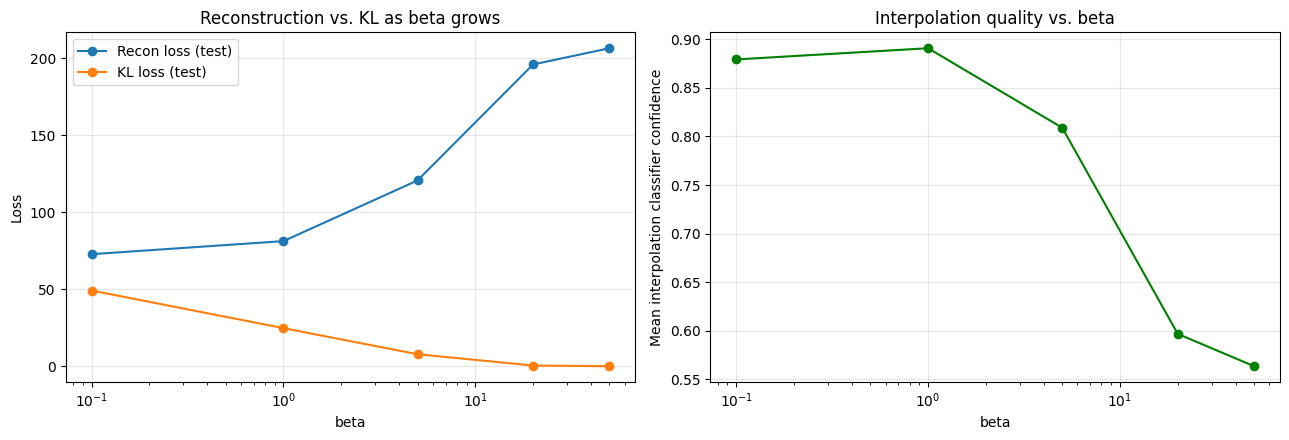

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

recon_vals = [results[b]["recon"] for b in BETAS]
kl_vals = [results[b]["kl"] for b in BETAS]
interp_vals = [results[b]["interp_confidence"] for b in BETAS]

axes[0].plot(BETAS, recon_vals, marker="o", label="Recon loss (test)")
axes[0].plot(BETAS, kl_vals, marker="o", label="KL loss (test)")
axes[0].set_xscale("log")
axes[0].set_xlabel("beta")
axes[0].set_ylabel("Loss")
axes[0].set_title("Reconstruction vs. KL as beta grows")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(BETAS, interp_vals, marker="o", color="green")
axes[1].set_xscale("log")
axes[1].set_xlabel("beta")
axes[1].set_ylabel("Mean interpolation classifier confidence")
axes[1].set_title("Interpolation quality vs. beta")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("beta_tradeoff.png", dpi=150)
plt.show()

## 7. Latent-space organization: PCA at low vs. high beta

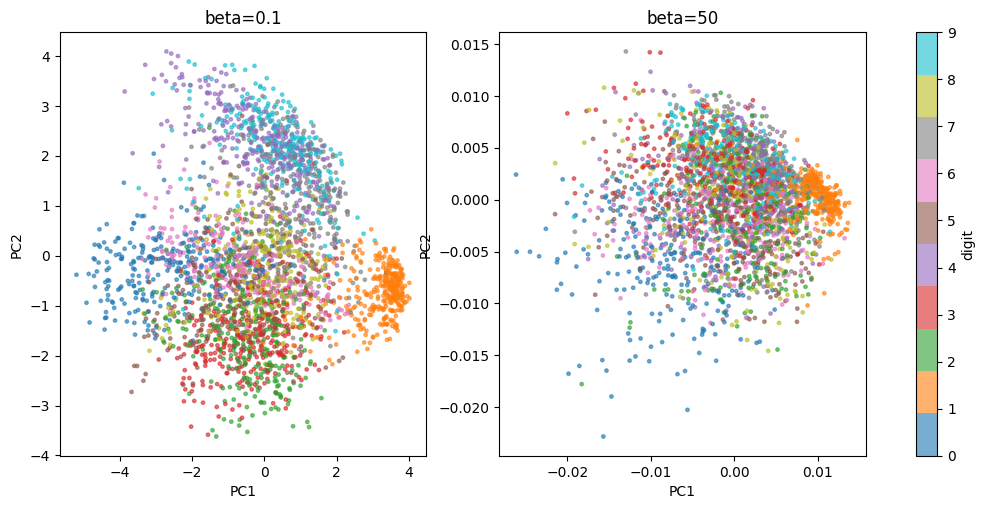

In [8]:
def get_latents(model, loader, n_max=3000):
    model.eval()
    mus, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            mu, _ = model.encode(xb)
            mus.append(mu.cpu().numpy())
            labels.append(yb.numpy())
            if sum(len(m) for m in mus) >= n_max:
                break
    return np.concatenate(mus)[:n_max], np.concatenate(labels)[:n_max]

low_beta, high_beta = BETAS[0], BETAS[-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, beta in zip(axes, [low_beta, high_beta]):
    mus, labels = get_latents(vae_models[beta], test_loader)
    coords = PCA(n_components=2, random_state=SEED).fit_transform(mus)
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", s=6, alpha=0.6)
    ax.set_title(f"beta={beta}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

cbar = fig.colorbar(scatter, ax=axes, ticks=range(10), label="digit")
plt.savefig("latent_space_pca.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Example interpolations, side by side across beta

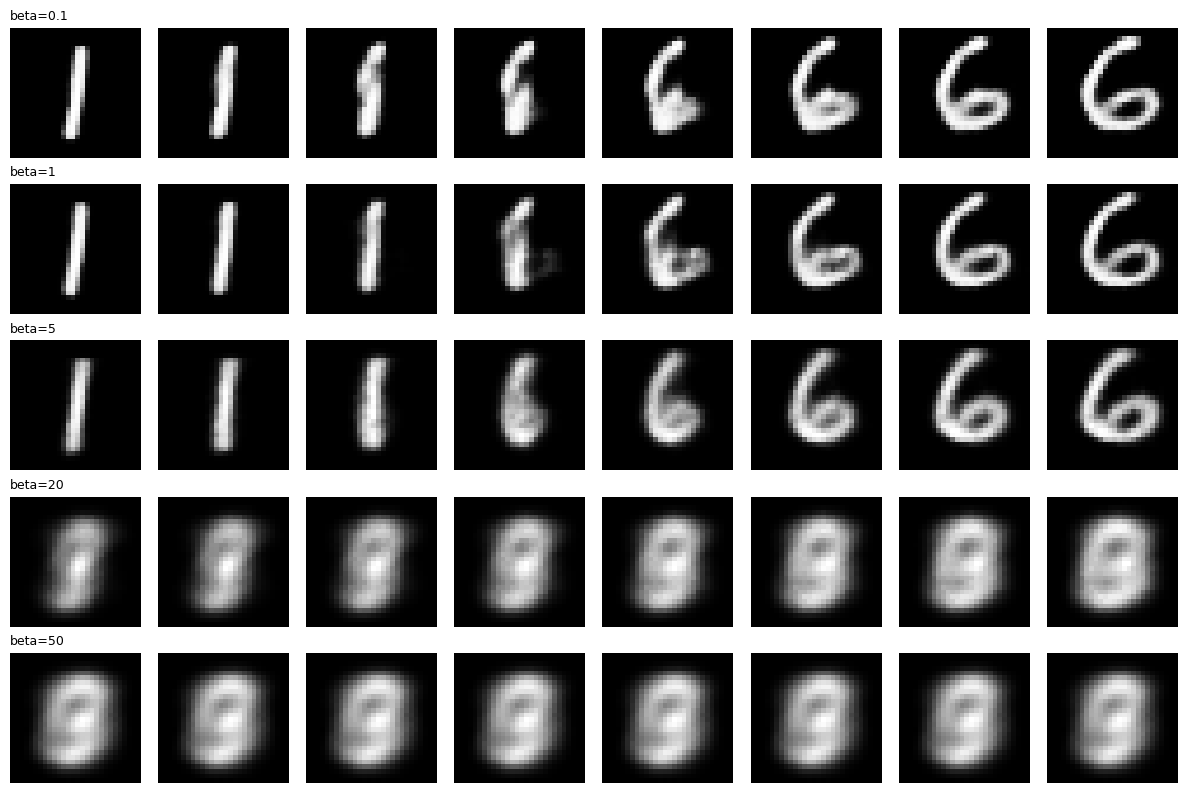

In [9]:
example_a, example_b = pairs[0]
alphas = torch.linspace(0, 1, 8, device=device)

fig, axes = plt.subplots(len(BETAS), 8, figsize=(12, 1.6 * len(BETAS)))
for row, beta in enumerate(BETAS):
    model = vae_models[beta]
    model.eval()
    with torch.no_grad():
        mu_a, _ = model.encode(example_a.unsqueeze(0).to(device))
        mu_b, _ = model.encode(example_b.unsqueeze(0).to(device))
        for col, alpha in enumerate(alphas):
            z = (1 - alpha) * mu_a + alpha * mu_b
            img = model.decode(z).cpu().squeeze().numpy()
            axes[row, col].imshow(img, cmap="gray")
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_title(f"beta={beta}", loc="left", fontsize=9)

plt.tight_layout()
plt.savefig("example_interpolations.png", dpi=150)
plt.show()

## 9. Samples from the prior (posterior collapse sanity check)

Sample z ~ N(0, I) directly (no encoder involved) and decode. At very high beta, if the model has collapsed, these samples may all look like the same blurry, generic average digit.

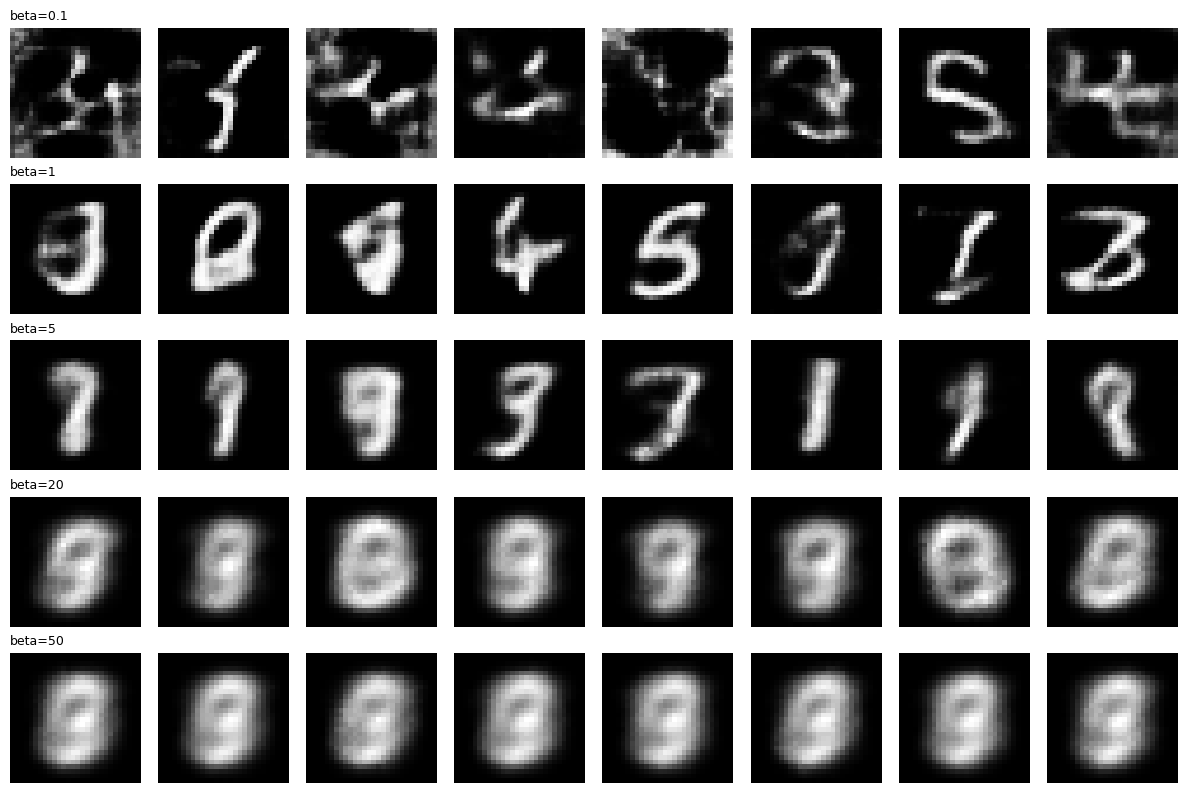

In [10]:
fig, axes = plt.subplots(len(BETAS), 8, figsize=(12, 1.6 * len(BETAS)))
torch.manual_seed(SEED)
for row, beta in enumerate(BETAS):
    model = vae_models[beta]
    model.eval()
    with torch.no_grad():
        z = torch.randn(8, LATENT_DIM, device=device)
        imgs = model.decode(z).cpu().numpy()
    for col in range(8):
        axes[row, col].imshow(imgs[col].squeeze(), cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(f"beta={beta}", loc="left", fontsize=9)

plt.tight_layout()
plt.savefig("prior_samples.png", dpi=150)
plt.show()

## 10. Demo: interactive latent-space interpolation

A small Gradio app that reuses the already-trained `vae_models` dict from Section 4 -- pick a
beta value and two digit classes, then drag a slider to interpolate between them in latent space.
This makes the beta trade-off tangible in real time: at low/moderate beta the interpolation
should look like it smoothly morphs from one digit into the other, while at high beta (e.g. 50)
it should barely change at all regardless of which digits or slider position you pick -- a live
demonstration of the posterior collapse shown in Figures 2/3/9 above.

In [11]:
!pip install -q gradio 2>/dev/null
import gradio as gr

# grab one example image per digit class from the test set, once
digit_to_image = {}
for img, label in test_full:
    label = int(label)
    if label not in digit_to_image:
        digit_to_image[label] = img
    if len(digit_to_image) == 10:
        break

@torch.no_grad()
def interpolate_demo(beta, digit_a, digit_b, alpha):
    model = vae_models[float(beta)]
    model.eval()

    img_a = digit_to_image[int(digit_a)].unsqueeze(0).to(device)
    img_b = digit_to_image[int(digit_b)].unsqueeze(0).to(device)

    mu_a, _ = model.encode(img_a)
    mu_b, _ = model.encode(img_b)

    z = (1 - alpha) * mu_a + alpha * mu_b
    decoded = model.decode(z).cpu().squeeze().numpy()

    return decoded  # gr.Image auto-scales a 2D float array in [0, 1]

demo = gr.Interface(
    fn=interpolate_demo,
    inputs=[
        gr.Dropdown(choices=[str(b) for b in BETAS], value=str(BETAS[1]), label="beta"),
        gr.Dropdown(choices=[str(d) for d in range(10)], value="1", label="Digit A"),
        gr.Dropdown(choices=[str(d) for d in range(10)], value="7", label="Digit B"),
        gr.Slider(minimum=0.0, maximum=1.0, value=0.5, step=0.01, label="Interpolation (A -> B)"),
    ],
    outputs=gr.Image(label="Decoded image", image_mode="L"),
    live=True,
    title="beta-VAE Latent Space Interpolation",
    description=(
        "Pick a beta and two digits, then drag the slider. Try beta=1 vs. beta=50 with the "
        "same digit pair -- at beta=50 the output should barely change regardless of the "
        "slider position, which is posterior collapse happening live."
    ),
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://903a3019a497f76f69.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
